In [102]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
from lattice_mp import SpinConfiguration

nx = 6
ny = 2
n = nx * ny

def get_m_vs_U(_delta = 1.):
    sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=_delta, lamb=0., print_data=True)

    mag = []
    _min = 4
    _max = 5
    steps = 10*(_max - _min) + 1
    u_range = np.logspace(_min, _max, base = 10, num = steps)

    rotation_map = np.array( [ [ (1 + (-1)**(x + y))/2 for x in range(nx) ] for y in range(ny) ] ).reshape((ny, nx))

    for u in tqdm(u_range):
        # U that should be used is up to 1e5
        sc.generate_hamiltonian(U = u)
        sc.get_eigva_eigve(10)
        _, gs_state = sc.get_ground_state()

        m = 0

        for repr, ii in sc.representatives.items():
            config = sc.map_int_to_config(repr)
            #m += np.square(np.abs(gs_state[ii])) * (np.sum(config * (config - 1))) / n
            rotated_cfg = config * rotation_map + (1 - config) * (1 - rotation_map)
            #m += np.square(np.abs(gs_state[ii])) * np.mean(rotated_cfg * np.roll(rotated_cfg, (-1, 0), axis= (0,1)))
            #m += np.square(np.abs(gs_state[ii])) * np.mean(rotated_cfg * np.roll(rotated_cfg, (0, -1), axis= (0,1)))
            m += np.square(np.abs(gs_state[ii])) * np.mean(rotated_cfg)
        
        mag.append(m)
    
    return u_range, mag


In [113]:
delta = 1.
u_range, M_1 = get_m_vs_U(delta)
m_1 = np.mean((np.sqrt(M_1) * u_range)[-10:])
m_1 = np.mean(M_1[-10:])
print(m_1)

delta = 2.
u_range, M_2 = get_m_vs_U(delta)
m_2 = np.mean((np.sqrt(M_2) * u_range)[-10:])
m_2 = np.mean(M_2[-10:])
print(m_2)

Processing 134596 states with 10 workers...


100%|██████████| 11/11 [00:00<00:00, 21.36it/s]


Total number of found representatives: 1358
Percent of repr in total states: 16.82%
Estimated matrix reduction: 5.9:1
Getting H took: 0.0673980712890625 s
Finding eigvals and eigvecs took: 0.0017008781433105469 s


100%|██████████| 11/11 [00:01<00:00,  6.94it/s]

0.5497788001131639
Processing 134596 states with 10 workers...



100%|██████████| 11/11 [00:00<00:00, 19.60it/s]


Total number of found representatives: 1358
Percent of repr in total states: 16.82%
Estimated matrix reduction: 5.9:1
Getting H took: 0.0677499771118164 s
Finding eigvals and eigvecs took: 0.0023469924926757812 s


100%|██████████| 11/11 [00:02<00:00,  3.74it/s]

0.5133686051858851


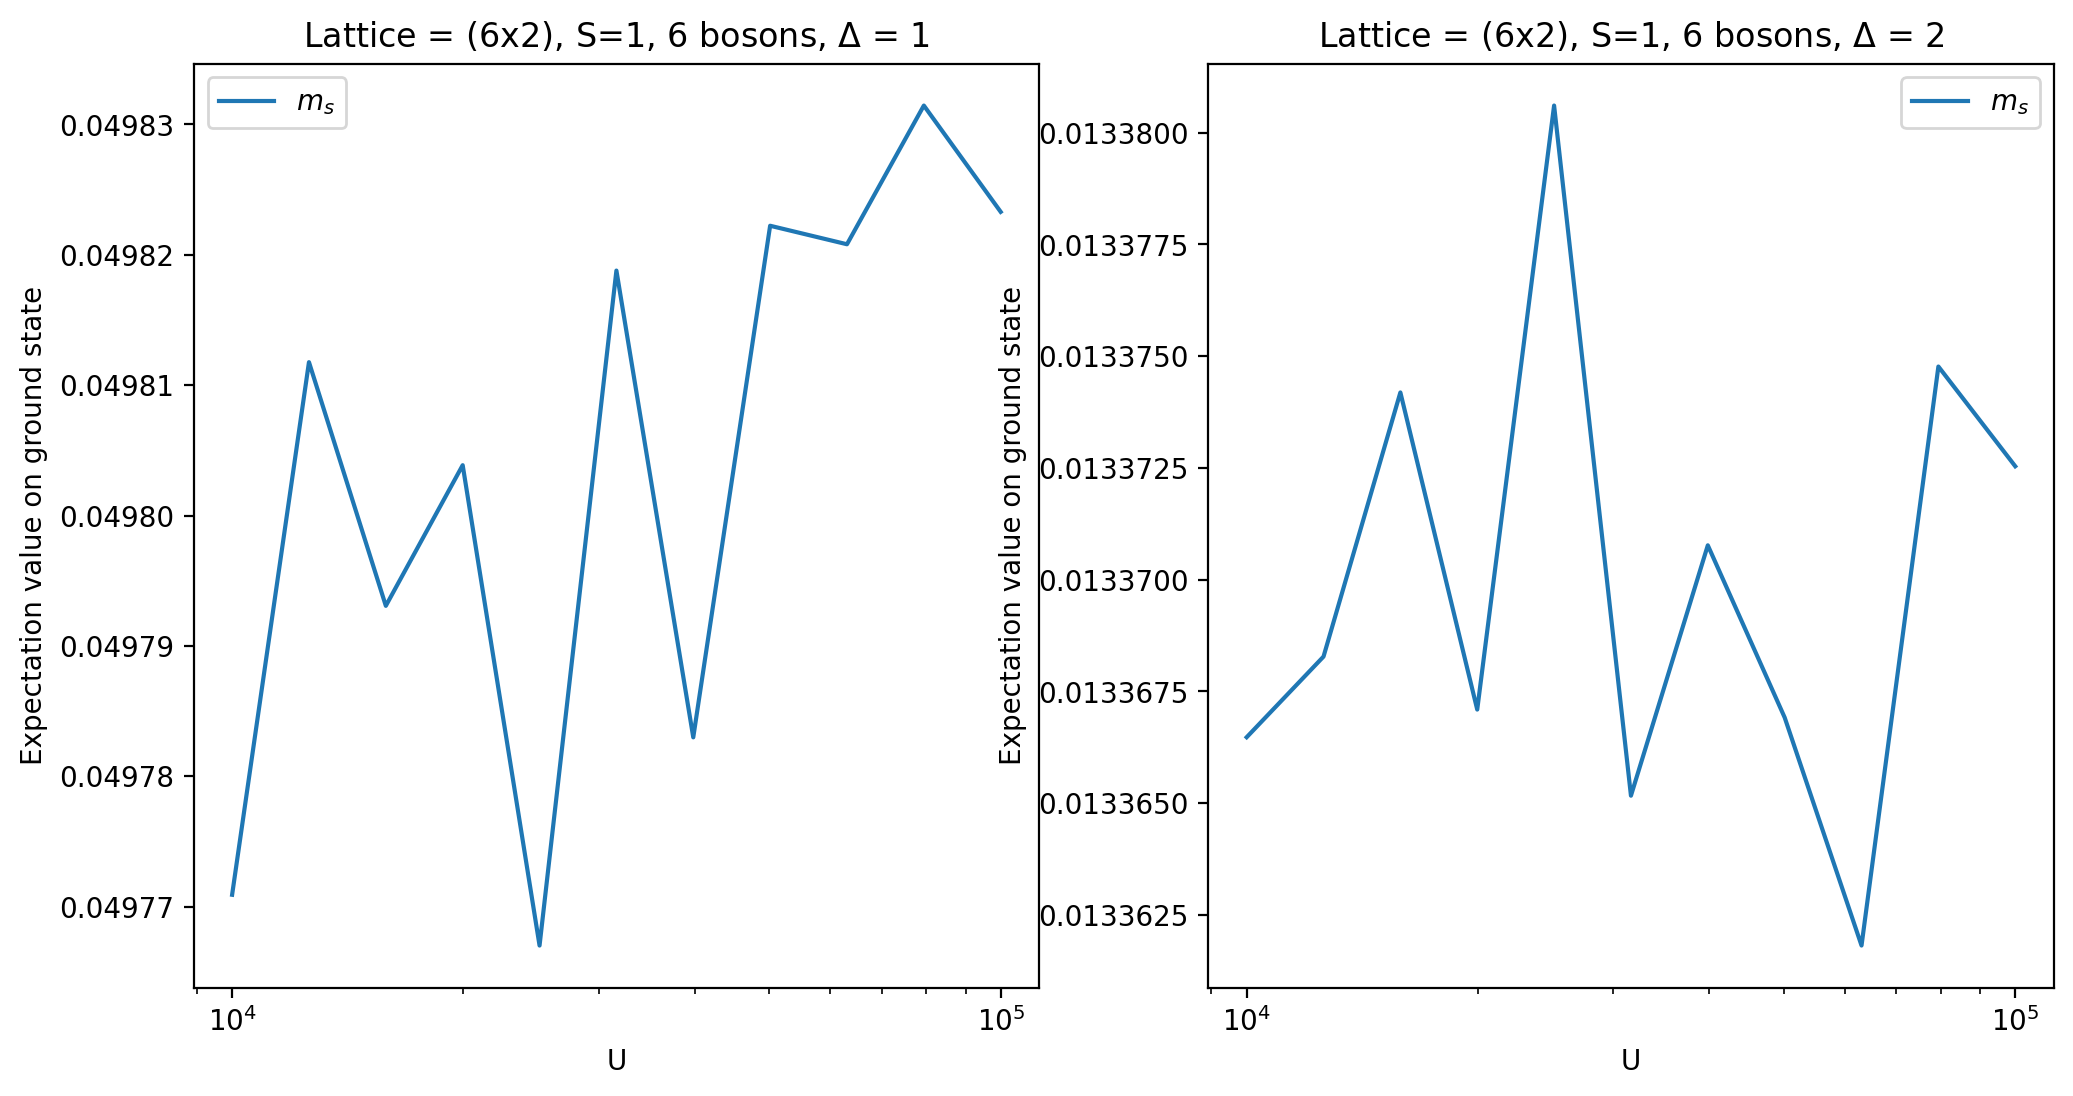

In [111]:
fig = plt.figure(figsize = (12, 6), dpi = 200)
plt.subplot(1, 2, 1)
plt.plot(u_range, M_1, label=r'$m_s$')
#plt.plot(u_range, M_1, label=r'$<\sum_{<ij>}n_i n_j>$')
#plt.plot(u_range, M_1, label=r'$<n(n-1)>$')
#plt.plot(u_range, M_1 * u_range, label=r'$U<n(n-1)>$')
#plt.plot(u_range, np.sqrt(M_1) * u_range, label=r'$U\cdot\sqrt{<n(n-1)>}$')
#plt.hlines(m_1, 1, 1e5, 'gray', '--')
plt.xscale('log')
plt.legend()
plt.xlabel('U')
plt.title(rf'Lattice = ({nx}x{ny}), S=1, {int(n/2)} bosons, $\Delta$ = {1}')
plt.ylabel('Expectation value on ground state')
plt.subplot(1, 2, 2)
plt.plot(u_range, M_2, label=r'$m_s$')
#plt.plot(u_range, M_2, label=r'$<\sum_{<ij>}n_i n_j>$')
#plt.plot(u_range, M_2, label=r'$<n(n-1)>$')
#plt.plot(u_range, M_2 * u_range, label=r'$U<n(n-1)>$')
#plt.plot(u_range, np.sqrt(M_2) * u_range, label=r'$U\cdot\sqrt{<n(n-1)>}$')
#plt.hlines(m_2, 1, 1e5, 'gray', '--')
plt.xscale('log')
plt.legend()
plt.xlabel('U')
plt.title(rf'Lattice = ({nx}x{ny}), S=1, {int(n/2)} bosons, $\Delta$ = {2}')
plt.ylabel('Expectation value on ground state')
plt.show()

In [106]:
"""
d_range = np.linspace(1., 3., 21)
print(d_range)

masses = []

for delta in d_range:
    u_range, M_1 = get_m_vs_U(delta)
    masses.append(np.mean((np.sqrt(M_1) * u_range)[-10:]))
"""

'\nd_range = np.linspace(1., 3., 21)\nprint(d_range)\n\nmasses = []\n\nfor delta in d_range:\n    u_range, M_1 = get_m_vs_U(delta)\n    masses.append(np.mean((np.sqrt(M_1) * u_range)[-10:]))\n'

In [107]:
"""
matrix = np.zeros( (len(masses), 2) )
matrix[:, 0] = d_range
matrix[:, 1] = masses
print(matrix)
np.savetxt('masses_vs_d.txt', matrix)
"""

"\nmatrix = np.zeros( (len(masses), 2) )\nmatrix[:, 0] = d_range\nmatrix[:, 1] = masses\nprint(matrix)\nnp.savetxt('masses_vs_d.txt', matrix)\n"

[0.30258751]


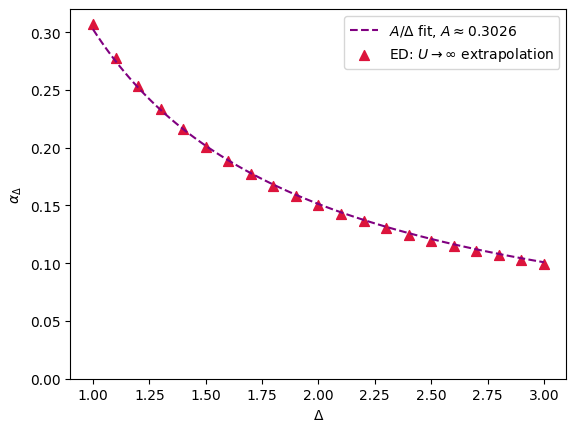

In [108]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.optimize as op

matrix = np.loadtxt('masses_vs_d.txt')
d_range = matrix[:, 0]
masses = matrix[:, 1]

def fit(pars):
    a = pars
    fun = a / d_range
    return np.sum( np.square(fun - masses) )

fun = op.minimize(fit, [.3])
print(fun.x)

_cont_d_range = np.linspace(np.min(d_range), np.max(d_range), 101)
a = fun.x
y = a / _cont_d_range
plt.plot(_cont_d_range, y, c='purple', ls='--', label = r'$A/\Delta$ fit, $A\approx0.3026$')
plt.scatter(d_range, masses, marker='^', s=50, c='crimson', label=r'ED: $U\to\infty$ extrapolation')
plt.ylim([0, .32])
plt.ylabel(r'$\alpha_\Delta$')
plt.xlabel(r'$\Delta$')
plt.legend()
plt.show()